# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [2]:
#!rm SUSY.csv

In [3]:
#!gunzip SUSY.csv.gz

In [4]:
ls -lh

 Volume in drive C is OS
 Volume Serial Number is 9041-8A82

 Directory of C:\Users\alexi\Documents\Github\DATA3402.Spring.2026\Labs\Lab.7



File Not Found


The data is provided as a comma separated file.

In [5]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 2.5G
-rw-r--r-- 1 alexi 197609 397K Apr  3 17:55 Lab.7.ipynb
-rw-r--r-- 1 alexi 197609 8.0M Mar 27 19:30 Lab.7.pdf
-rw-r--r-- 1 alexi 197609 228M Apr  3 17:52 SUSY-small.csv
-rw-r--r-- 1 alexi 197609 2.3G Mar 27 20:20 SUSY.csv


We see that we have 5 million datapoints.

In [7]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [8]:
!head -500000 SUSY.csv > SUSY-small.csv

In [9]:
ls -lh

 Volume in drive C is OS
 Volume Serial Number is 9041-8A82

 Directory of C:\Users\alexi\Documents\Github\DATA3402.Spring.2026\Labs\Lab.7



File Not Found


In [10]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [11]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [12]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [13]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [14]:
FeatureNames

['MT2',
 'S_R',
 'M_Delta_R',
 'dPhi_r_b',
 'R',
 'cos_theta_r1',
 'M_R',
 'M_TR_2',
 'MET_rel',
 'axial_MET']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [16]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [17]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [18]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


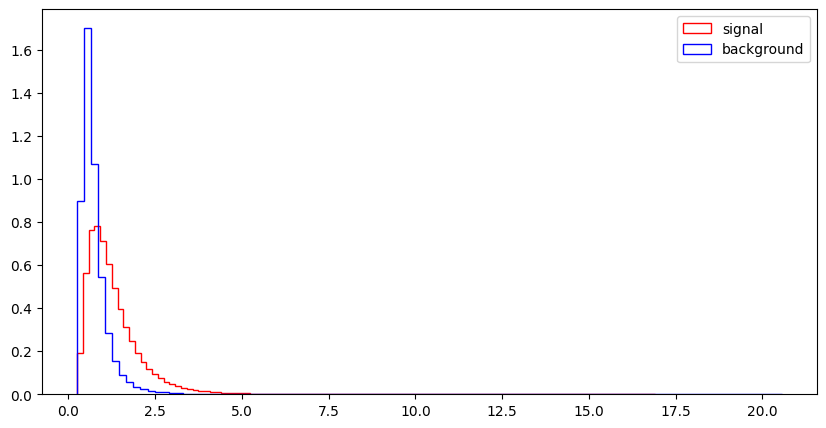

l_1_eta


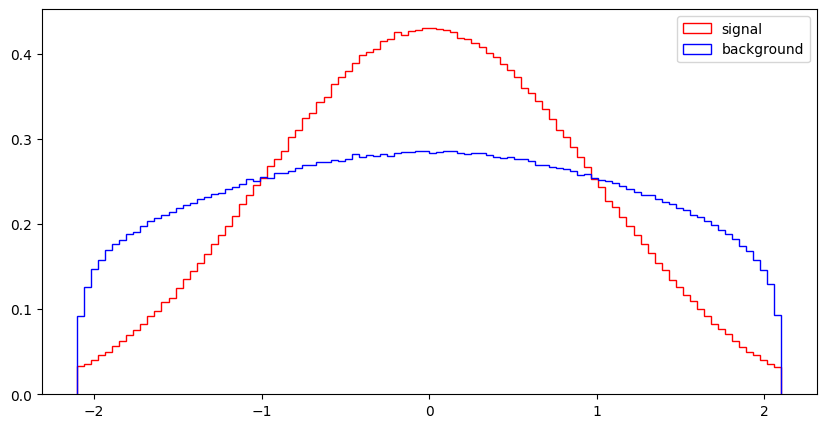

l_1_phi


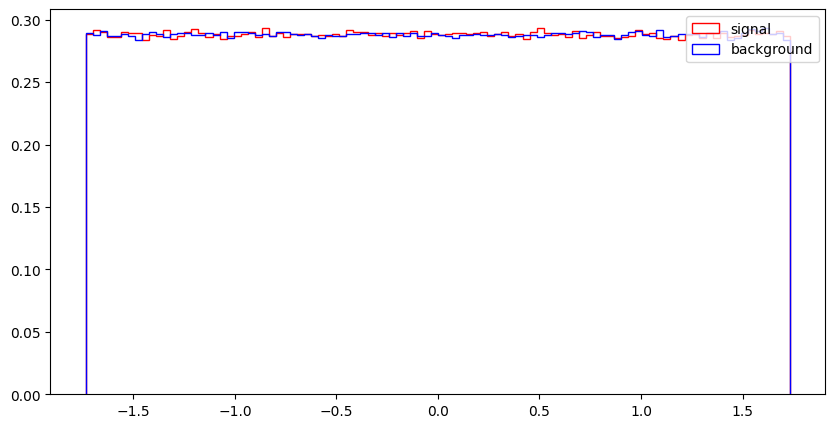

l_2_pT


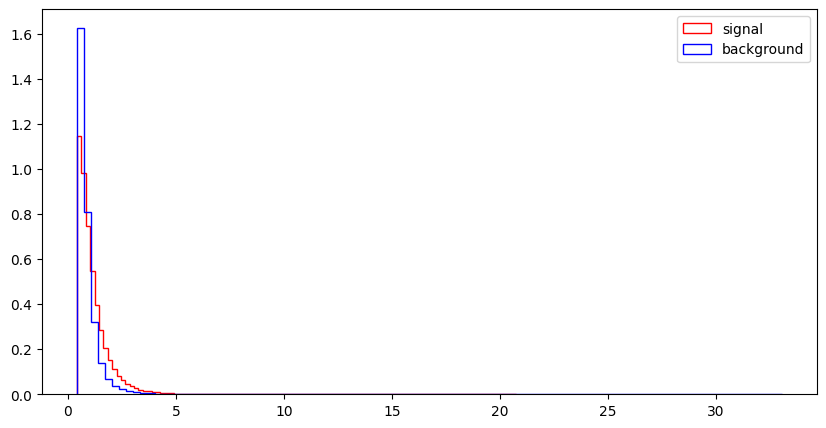

l_2_eta


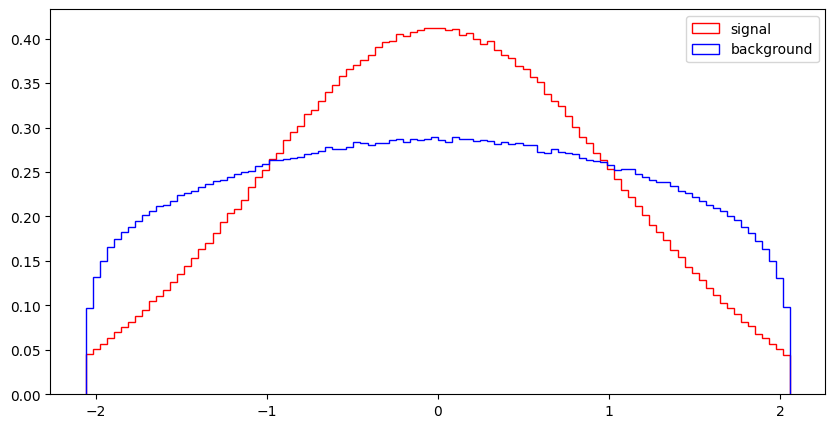

l_2_phi


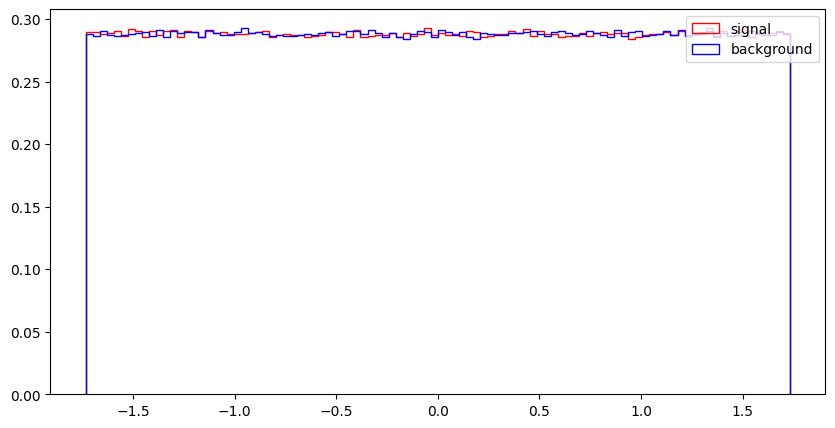

MET


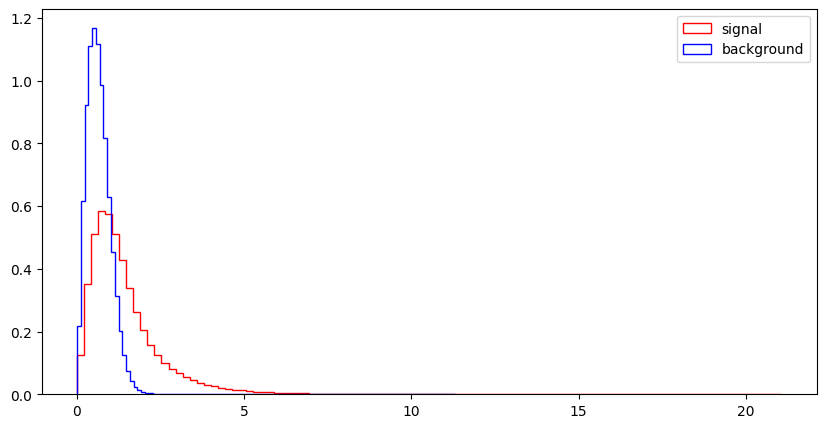

MET_phi


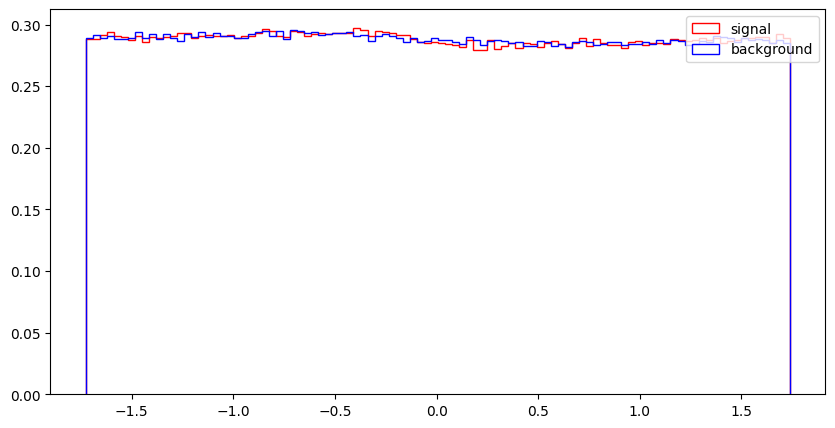

MET_rel


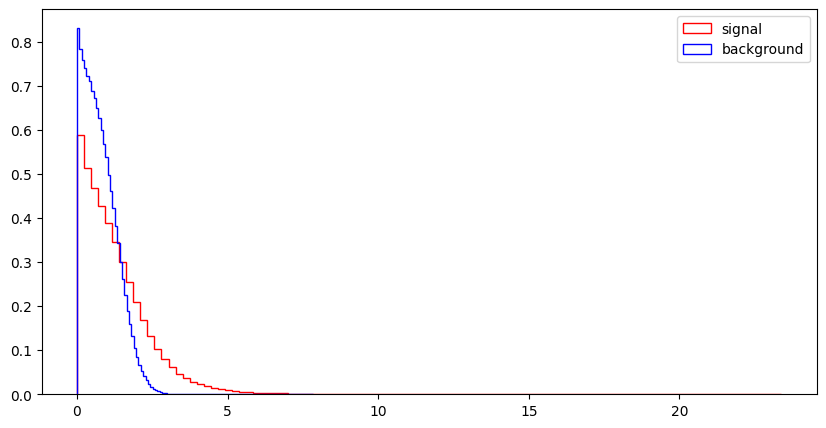

axial_MET


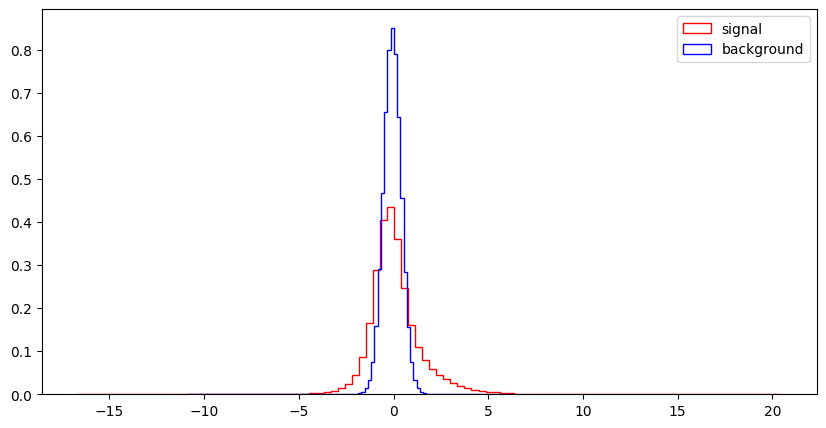

M_R


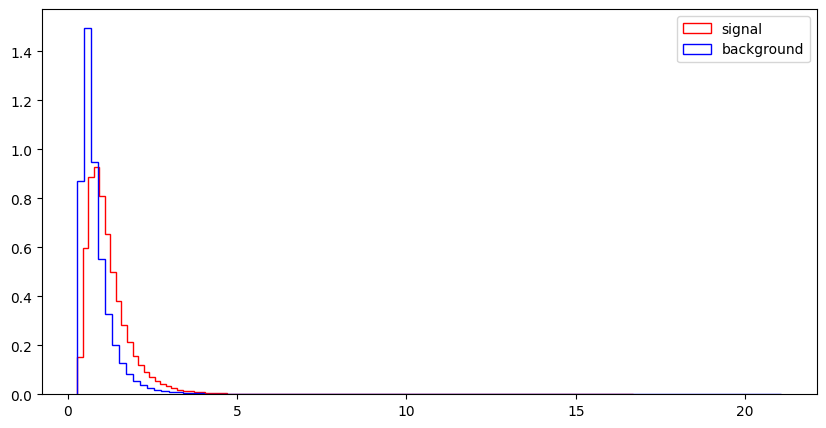

M_TR_2


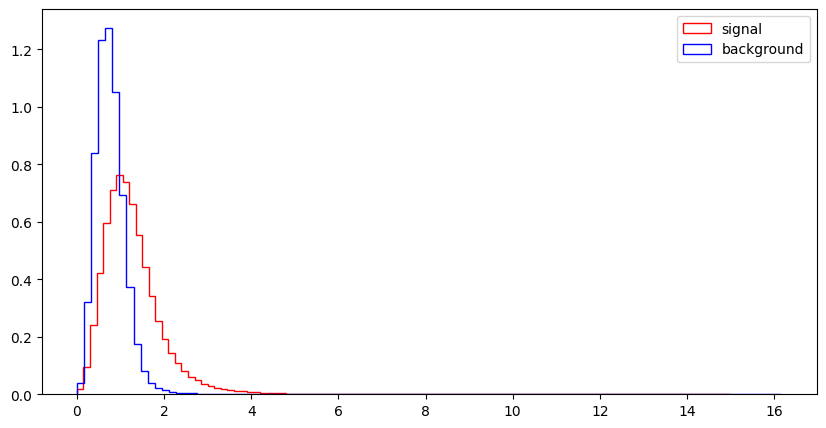

R


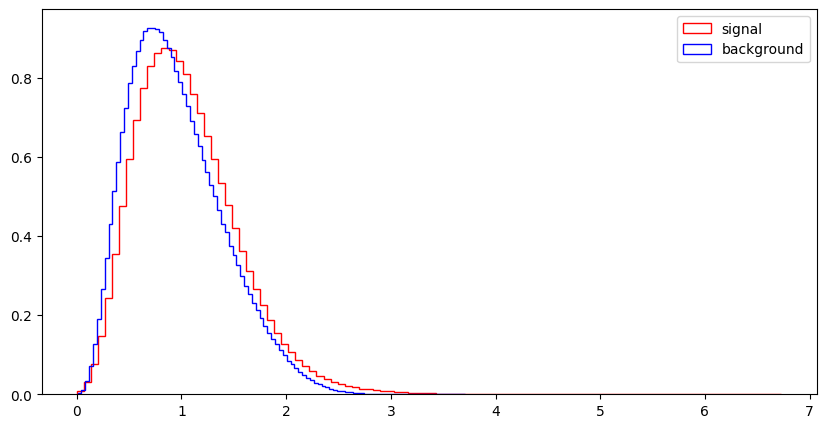

MT2


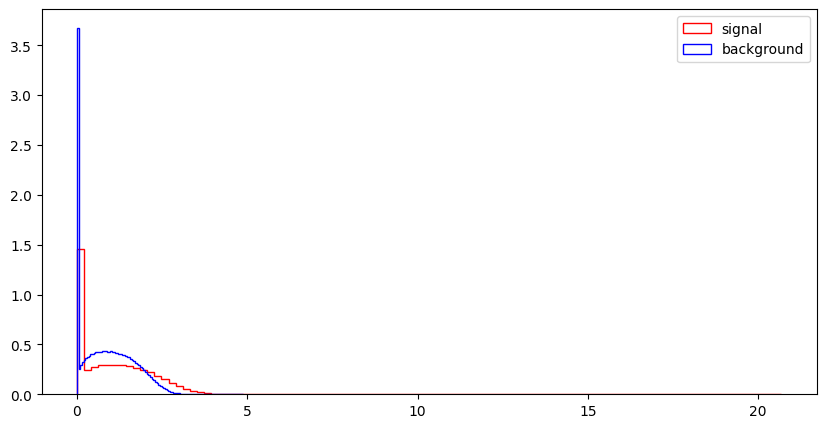

S_R


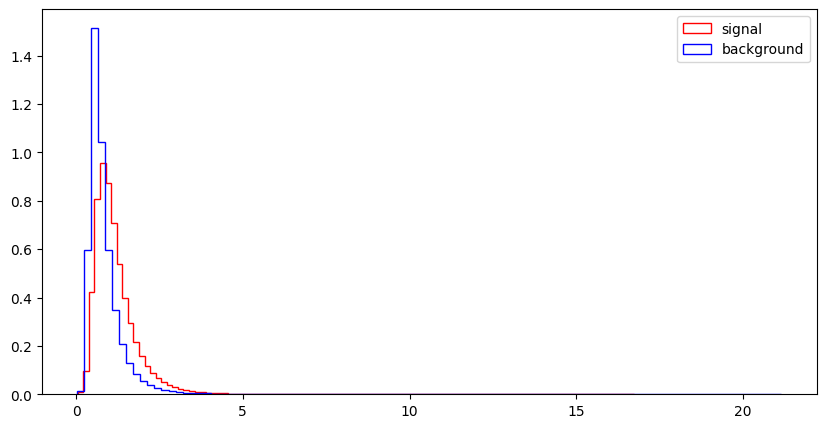

M_Delta_R


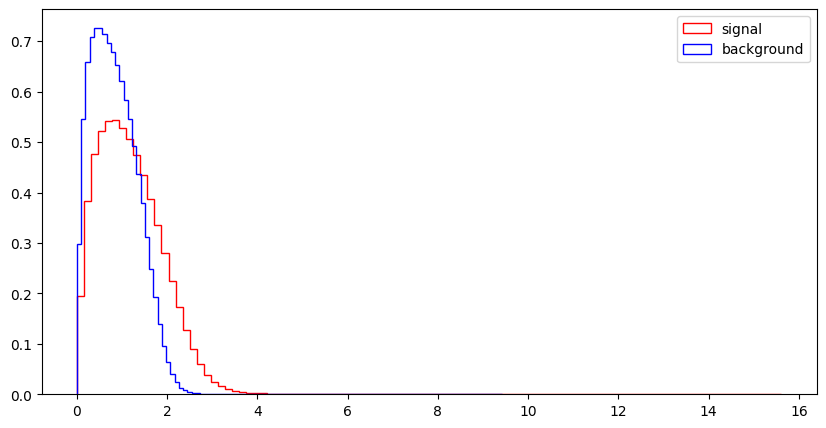

dPhi_r_b


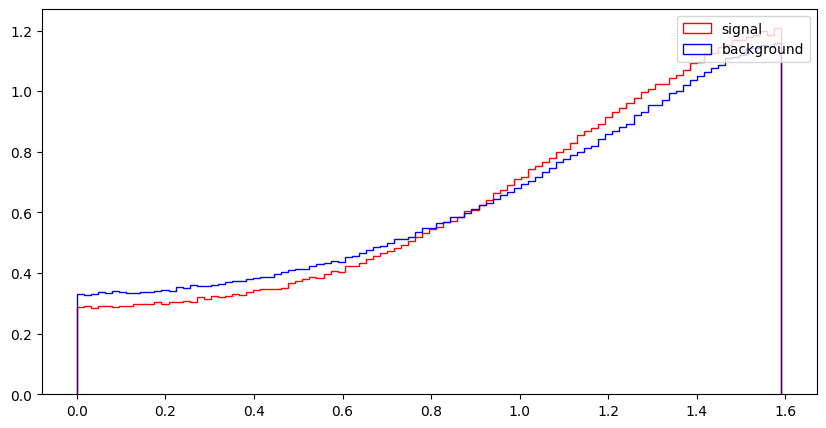

cos_theta_r1


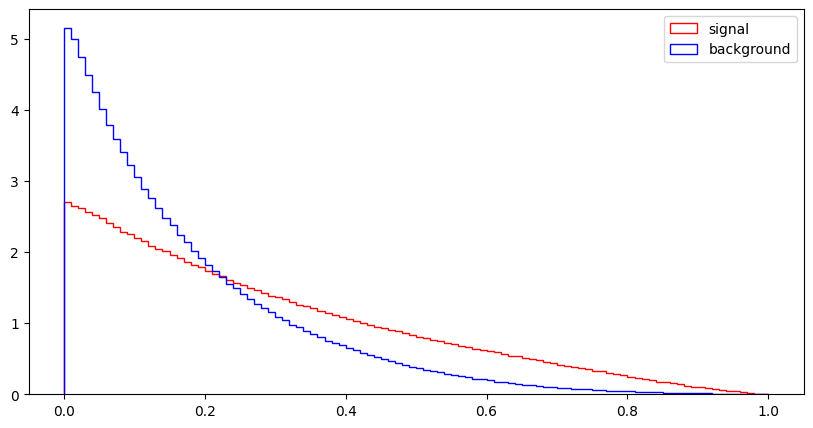

In [19]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

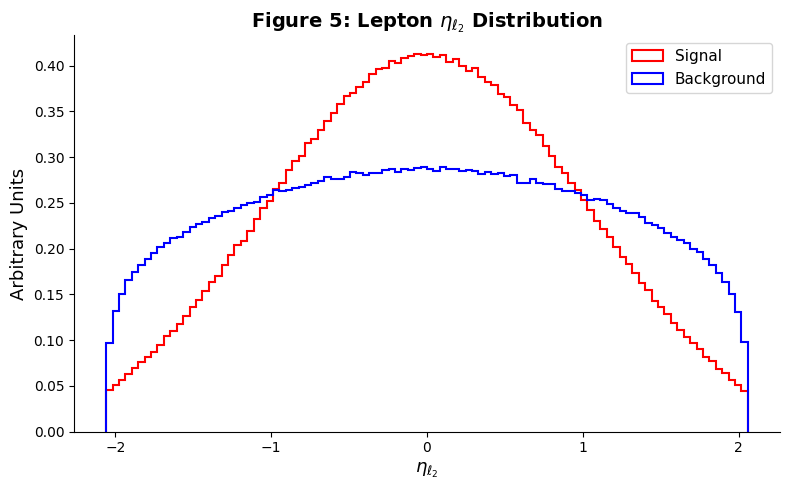

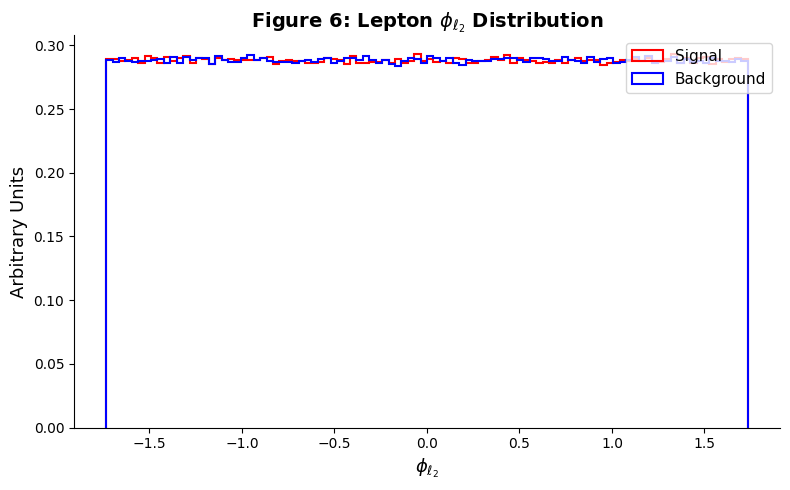

In [20]:
def plot_figure(var, xlabel, title, bins=100, figsize=(8, 5)):
##corrects the formatting and adds axis titles from incorrect plots
    fig, ax = plt.subplots(figsize=figsize)

    ##Computes the data from shared bins
    all_data = np.concatenate([df_sig[var].values, df_bkg[var].values])
    bin_edges = np.linspace(all_data.min(), all_data.max(), bins + 1)

    ##Shows overlap with signal and background
    ax.hist(df_sig[var].values, bins=bin_edges,
            histtype='step', color='red', linewidth=1.5,
            label='Signal', density=True)

    ax.hist(df_bkg[var].values, bins=bin_edges,
            histtype='step', color='blue', linewidth=1.5,
            label='Background', density=True)

    ##Adds labels, title, and legend
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('Arbitrary Units', fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11, frameon=True)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_ylim(bottom=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

low_level  = ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 'l_2_phi', 'MET', 'MET_phi']
high_level = ['MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']

##Figure 5
plot_figure('l_2_eta',
            xlabel=r'$\eta_{\ell_2}$',
            title=r'Figure 5: Lepton $\eta_{\ell_2}$ Distribution')

##Figure 6
plot_figure('l_2_phi',
            xlabel=r'$\phi_{\ell_2}$',
            title=r'Figure 6: Lepton $\phi_{\ell_2}$ Distribution')

### Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

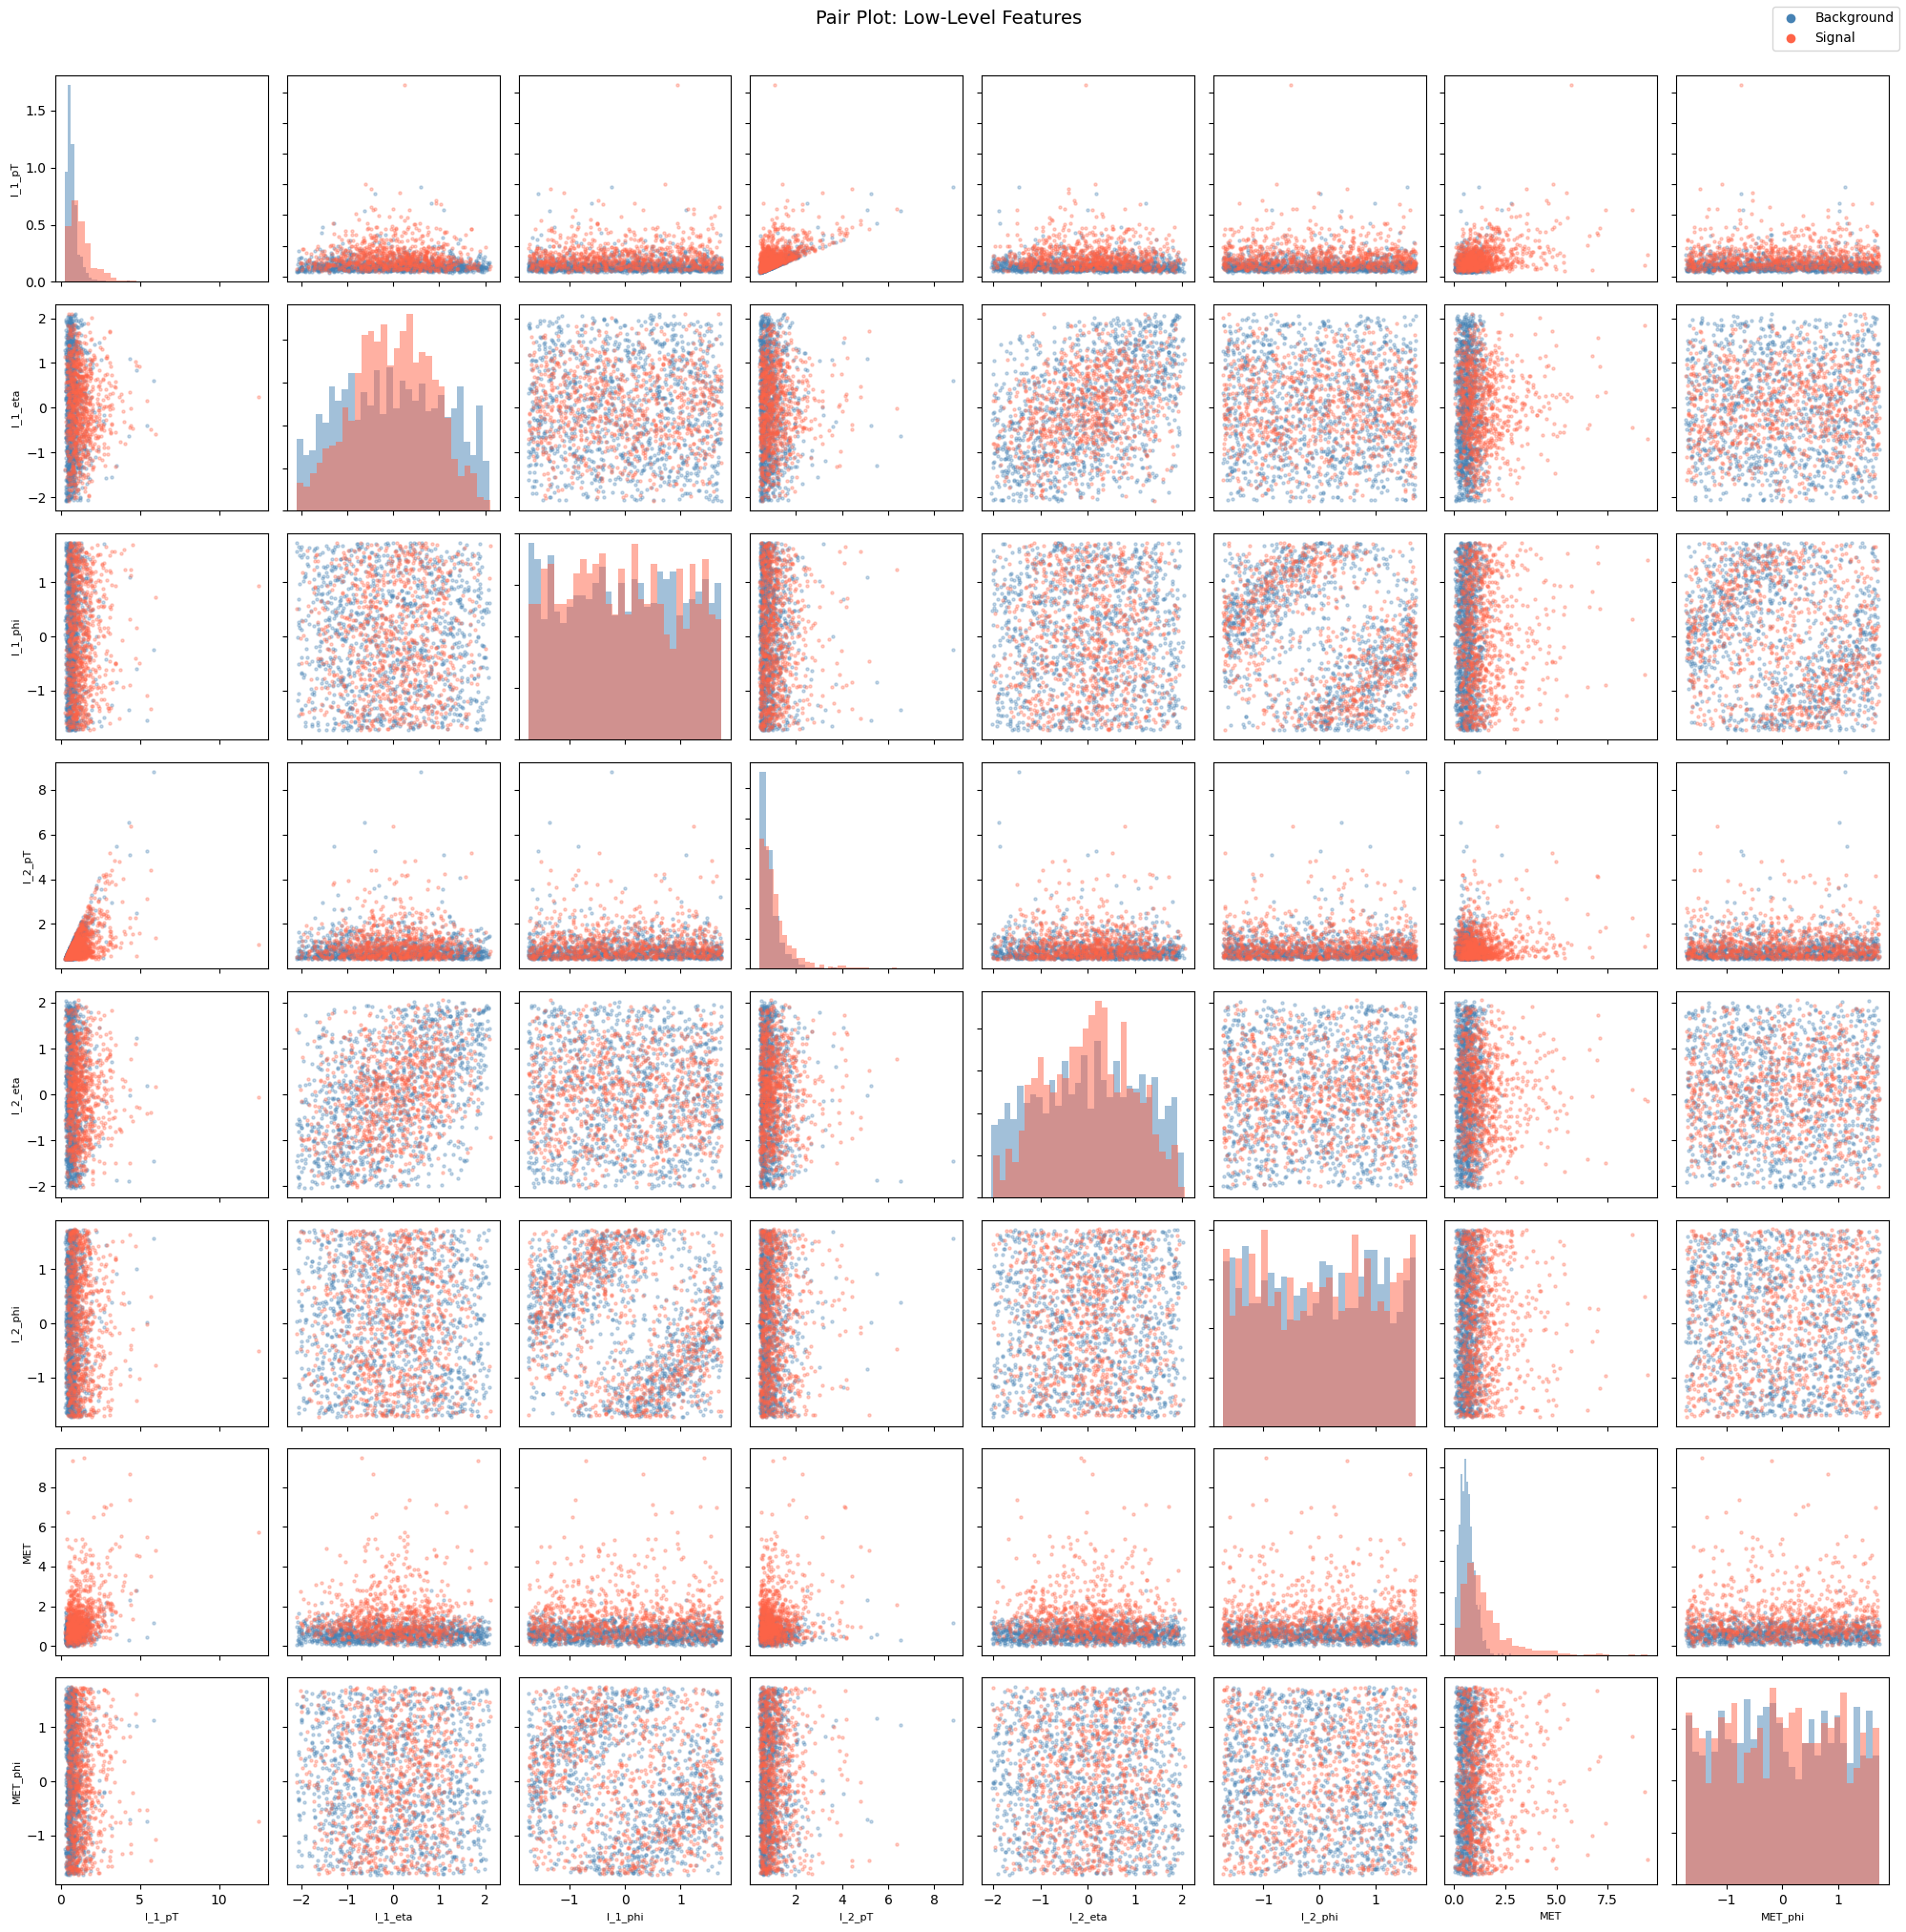

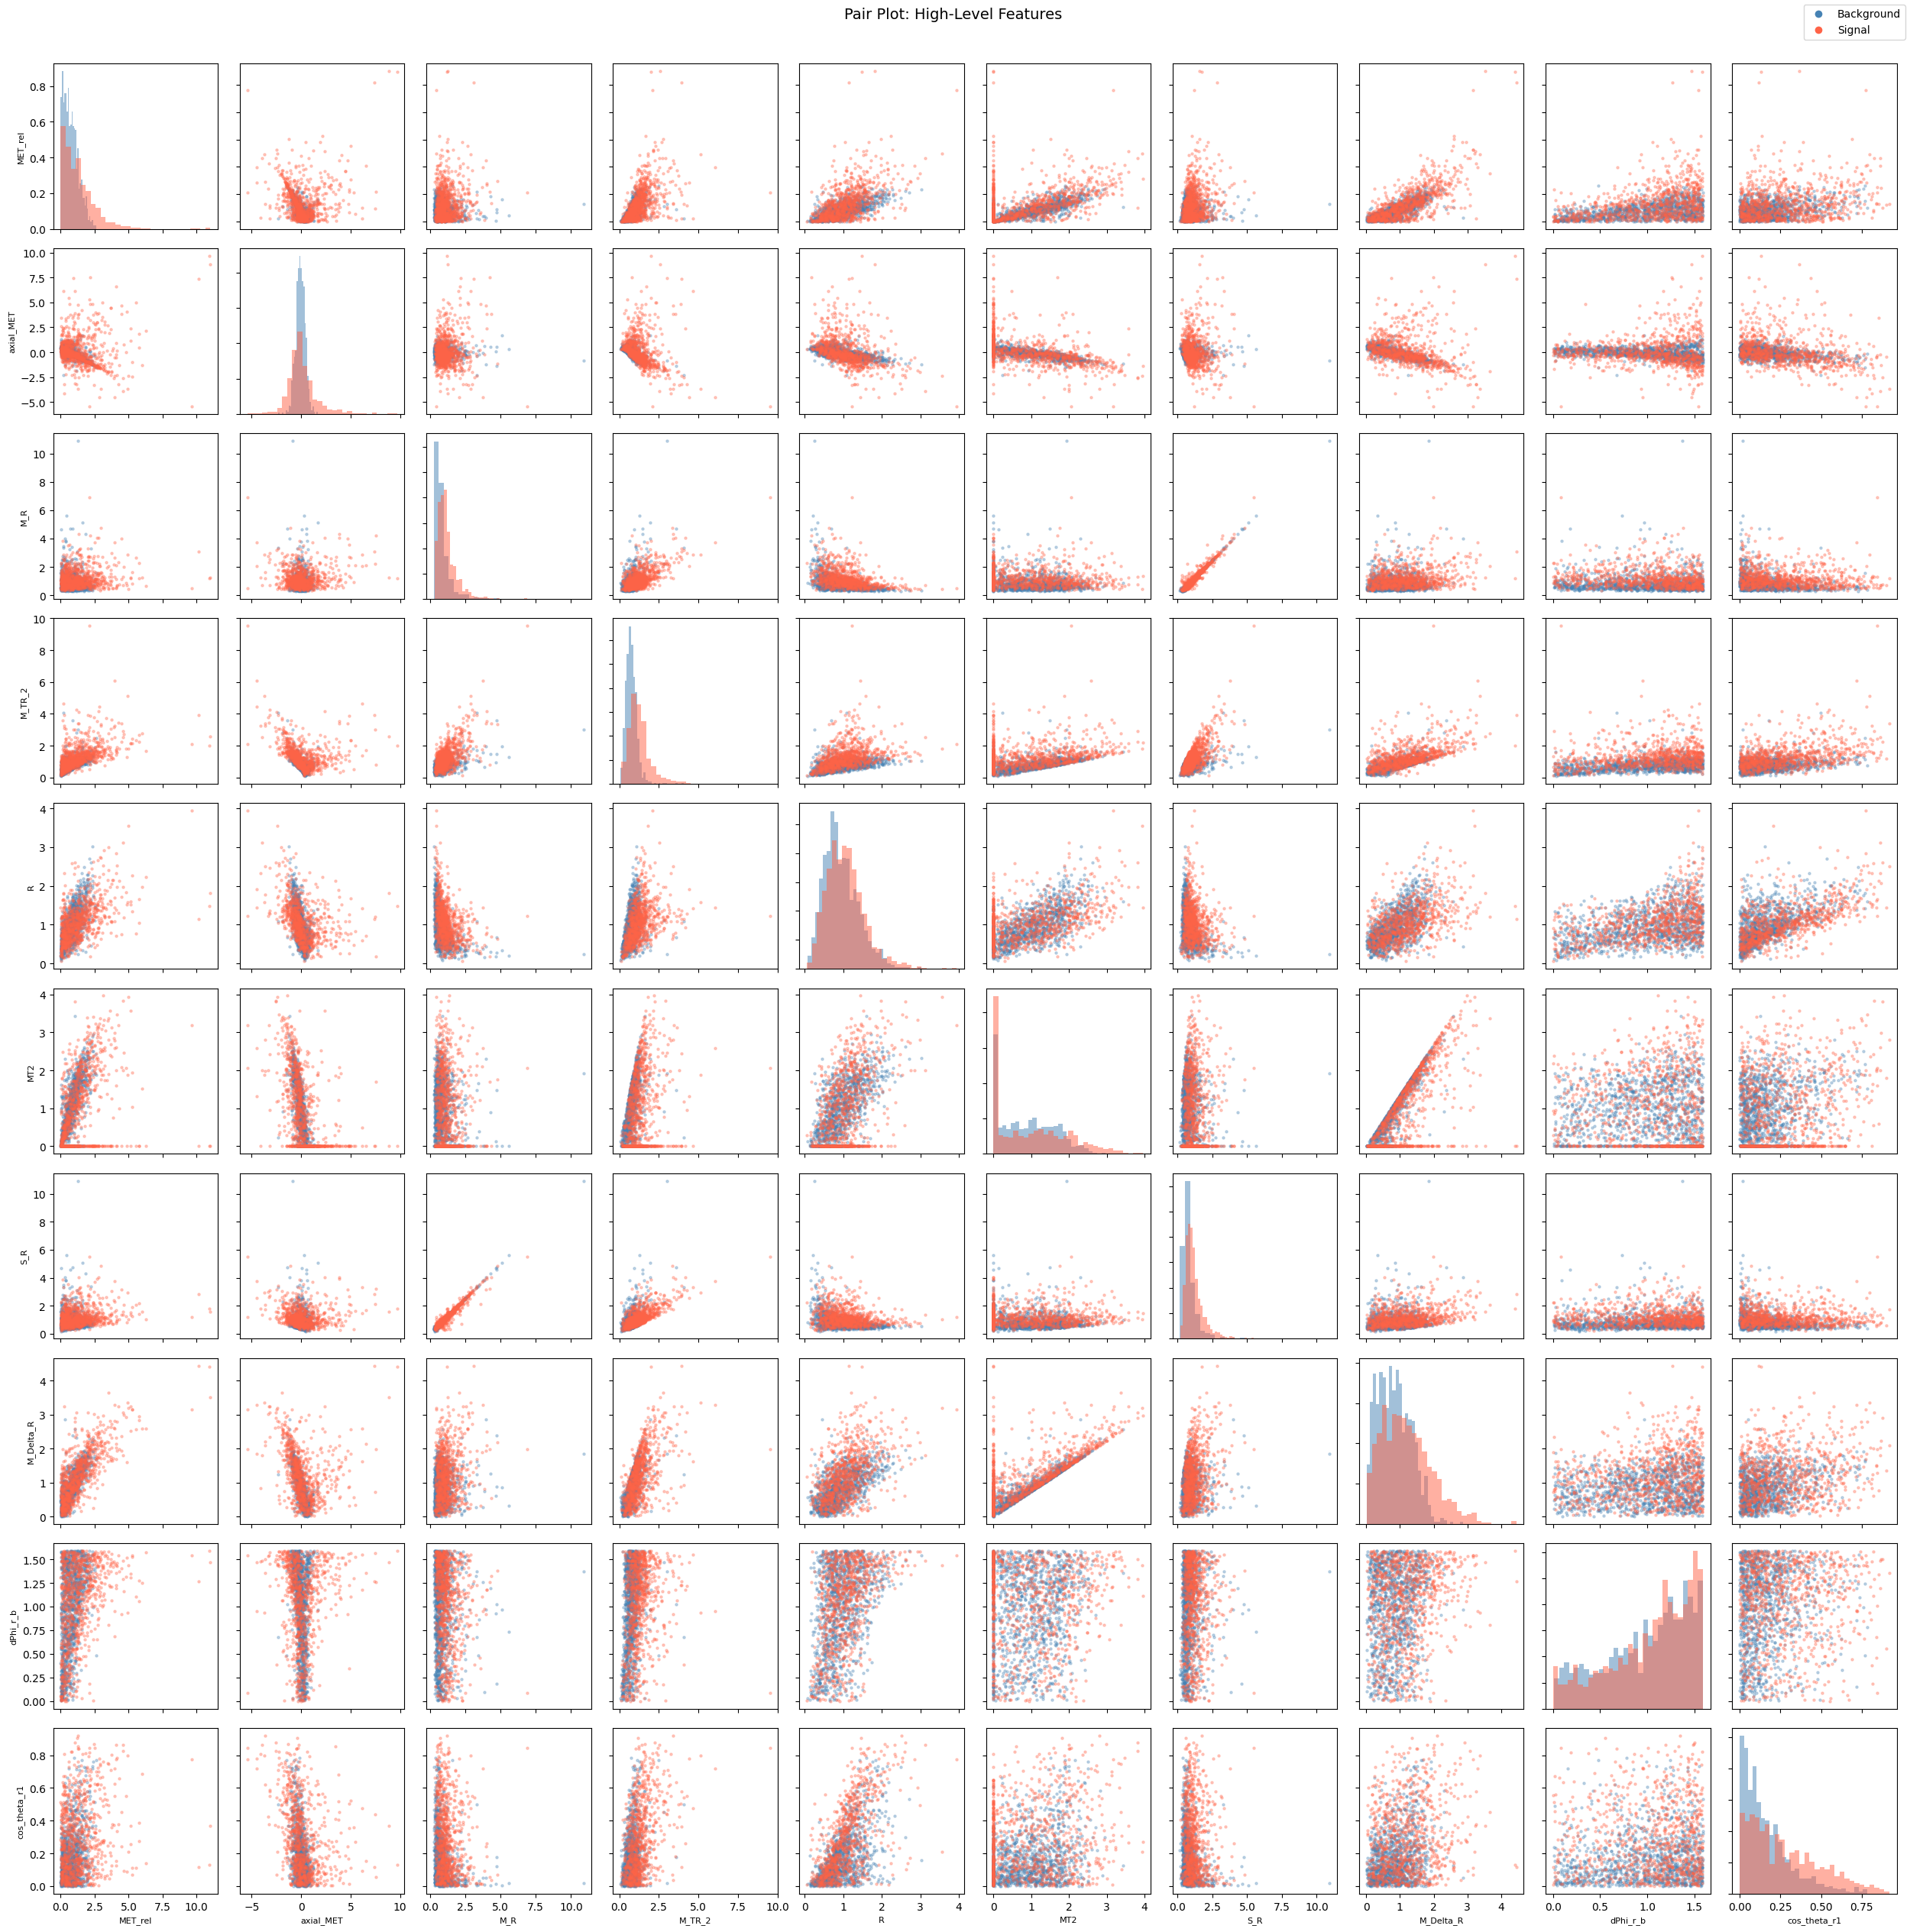

In [21]:
##Part a

##Creates pair plots for signal and background
def pair_plot(df, features, hue_col='signal', sample_n=2000, title=''):
    data = df.sample(n=sample_n, random_state=42)
    
    classes = data[hue_col].unique()
    colors = {0: 'steelblue', 1: 'tomato'}
    labels = {0: 'Background', 1: 'Signal'}
    
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(n * 2.5, n * 2.5))
    fig.suptitle(title, fontsize=14, y=1.01)
    
    for i, feat_y in enumerate(features):
        for j, feat_x in enumerate(features):
            ax = axes[i, j]
            for cls in classes:
                subset = data[data[hue_col] == cls]
                if i == j:
                    ax.hist(subset[feat_x], bins=30, alpha=0.5,
                            color=colors[cls], label=labels[cls], density=True)
                else:
                    ax.scatter(subset[feat_x], subset[feat_y],
                               alpha=0.3, s=5, color=colors[cls], label=labels[cls])
            
            if i == n - 1:
                ax.set_xlabel(feat_x, fontsize=8)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(feat_y, fontsize=8)
            else:
                ax.set_yticklabels([])
    
    handles = [plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=colors[c], label=labels[c], markersize=8)
               for c in classes]
    fig.legend(handles=handles, loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

low_level  = ['l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 'l_2_phi', 'MET', 'MET_phi']
high_level = ['MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']

pair_plot(df, low_level,  title='Pair Plot: Low-Level Features')
pair_plot(df, high_level, title='Pair Plot: High-Level Features')

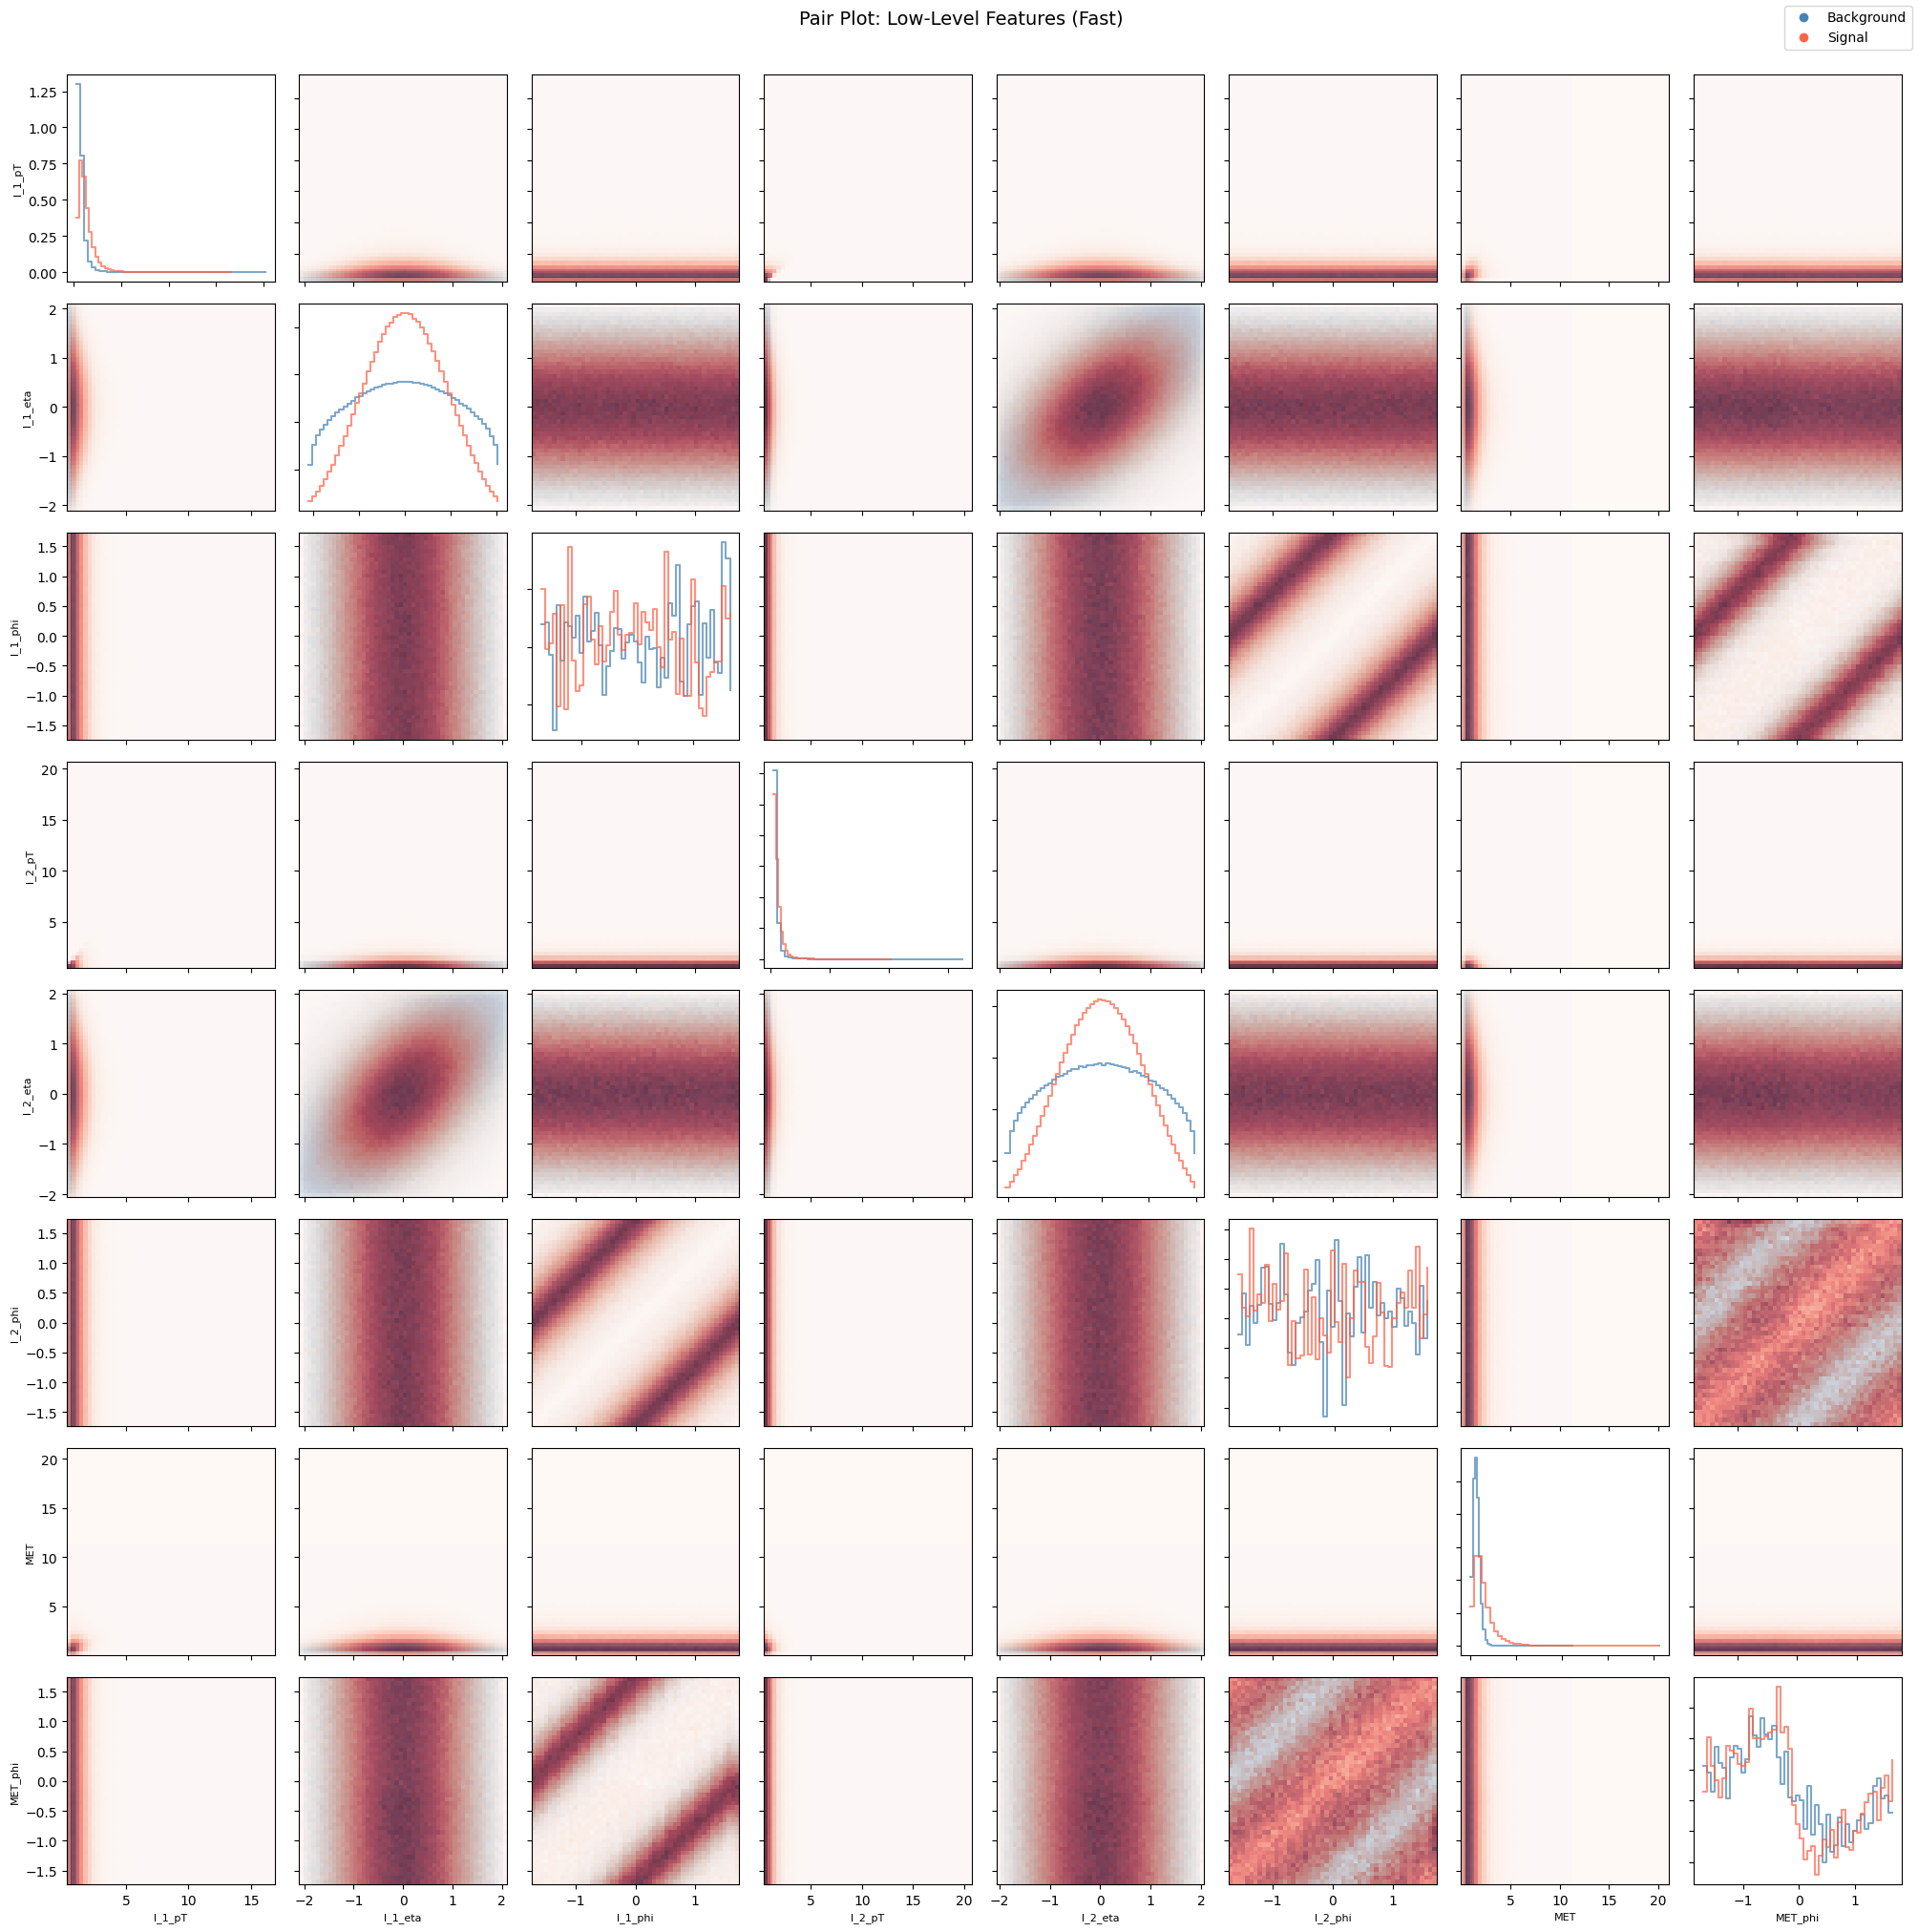

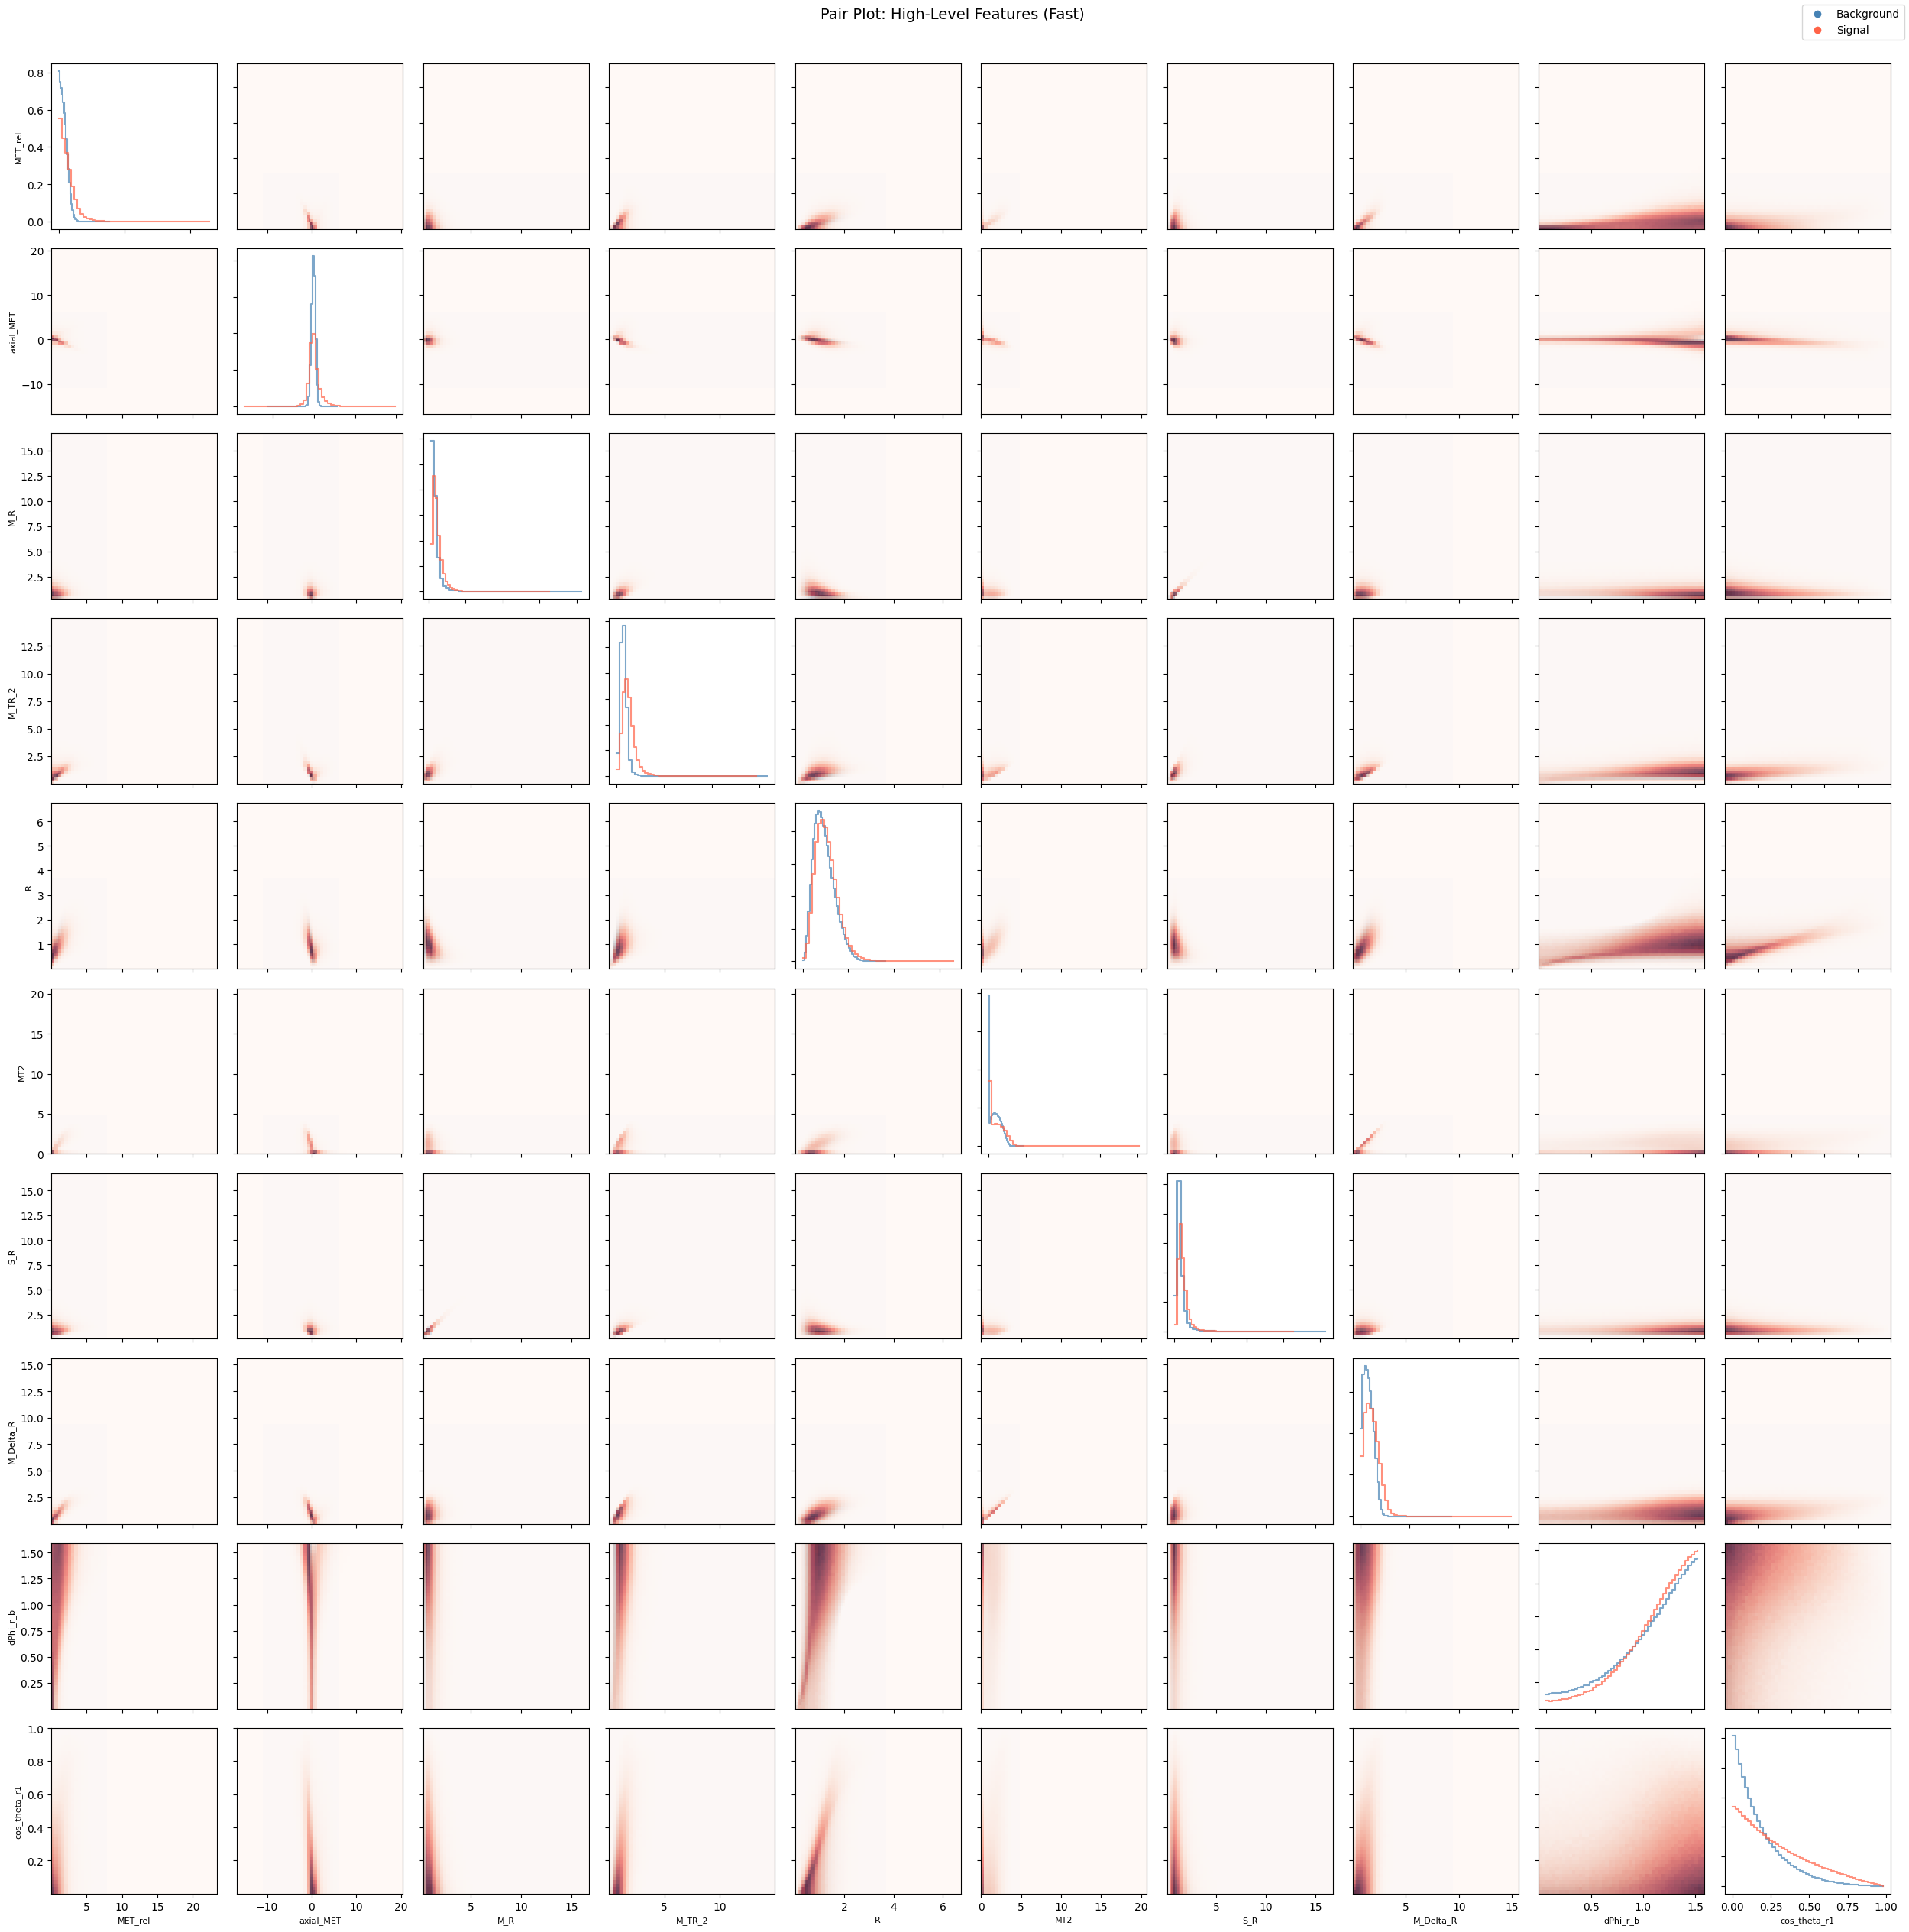

In [22]:
##Part B

##Generates faster by using pre computed histograms

def pair_plot_fast(df, features, hue_col='signal', bins=50, title=''):
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(n * 2.5, n * 2.5))
    fig.suptitle(title, fontsize=14, y=1.01)

    classes = df[hue_col].unique()
    colors  = {0: 'Blues', 1: 'Reds'}
    colors1 = {0: 'steelblue', 1: 'tomato'}
    labels  = {0: 'Background', 1: 'Signal'}

    ##Arrays are pulled once outside the for loop
    feature_data = {cls: {f: df.loc[df[hue_col] == cls, f].values
                          for f in features}
                    for cls in classes}

    for i, feat_y in enumerate(features):
        for j, feat_x in enumerate(features):
            ax = axes[i, j]
            for cls in classes:
                x = feature_data[cls][feat_x]
                y = feature_data[cls][feat_y]

                if i == j:
                    ##Pre computes histogram on diagonal
                    counts, bin_edges = np.histogram(x, bins=bins, density=True)
                    ax.step(bin_edges[:-1], counts, where='post',
                            color=colors1[cls], alpha=0.7, label=labels[cls])
                else:
                    ##Uses a histogram instead of scatter plots
                    ax.hist2d(x, y, bins=bins, cmap=colors[cls], alpha=0.6)

            if i == n - 1:
                ax.set_xlabel(feat_x, fontsize=8)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(feat_y, fontsize=8)
            else:
                ax.set_yticklabels([])

    handles = [plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=colors1[c], label=labels[c], markersize=8)
               for c in classes]
    fig.legend(handles=handles, loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

pair_plot_fast(df, low_level,  title='Pair Plot: Low-Level Features (Fast)')
pair_plot_fast(df, high_level, title='Pair Plot: High-Level Features (Fast)')

In [23]:
##Part C

For the greatest separation between signal and background, high-level features such as R
and MT2 are best suited for displaying such on the histograms. As for low-level features,
MET is the best choice, but the high-level features are still more ideal because the low-
level features only account for raw measurements.

SyntaxError: invalid syntax (4062602752.py, line 3)

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [ ]:
pip install tabulate

In [ ]:
##Part B

import numpy as np
from IPython.display import HTML, display
import tabulate as tb

##takes the data and feature variable names, creates matrices with numpy, then displays
##as tables through tabulate
def compute_and_display_matrices(df, features, title=""):
    ##Gathers the data and computes matrices
    data = df[features].values

    cov_matrix  = np.cov(data.T)
    corr_matrix = np.corrcoef(data.T)

    ##Part C
    def matrix_to_table(matrix, features, sig_figs=4):
        rows = []
        for i, feat in enumerate(features):
            row = [feat] + [f"{val:.{sig_figs}f}" for val in matrix[i]]
            rows.append(row)
        return rows

    def styled_html(html, subtitle):
        return f"""
        <h3 style='font-family:sans-serif; color:#333'>{title} — {subtitle}</h3>
        <style>
            table {{border-collapse: collapse; font-family: monospace; font-size: 11px;}}
            th, td {{border: 1px solid #ccc; padding: 5px 10px; text-align: right;}}
            th {{background-color: #f0f0f0; font-weight: bold;}}
            tr:nth-child(even) {{background-color: #f9f9f9;}}
        </style>
        {html}
        """

    headers = [""] + features

    ##Covariance matrix
    cov_table = matrix_to_table(cov_matrix, features)
    display(HTML(styled_html(
        tb.tabulate(cov_table, tablefmt='html', headers=headers),
        "Covariance Matrix"
    )))

    ##Correlation matrix
    corr_table = matrix_to_table(corr_matrix, features)
    display(HTML(styled_html(
        tb.tabulate(corr_table, tablefmt='html', headers=headers),
        "Correlation Matrix"
    )))

    return cov_matrix, corr_matrix

##Part D
all_features = low_level + high_level
cov_all,  corr_all  = compute_and_display_matrices(df, all_features, title="All Features")
cov_low,  corr_low  = compute_and_display_matrices(df, low_level,    title="Low-Level Features")
cov_high, corr_high = compute_and_display_matrices(df, high_level,   title="High-Level Features")


Hint: Example code for embedding a `tabulate` table into a notebook:

In [ ]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [ ]:
##Exercise 5.1
## 1: x > xc - where the signal has higher value
## 2: x < xc - where the signal has lower value  
## 3: |x- µ| > xc - where signal is more spread out
## 4: |x- µ| < xc - signal is more present near the mean value

selection_strategy = {
    'l_1_pT'      : 1,  ##signal is more present near higher pT
    'l_1_eta'     : 4,  ##signal is at 0
    'l_1_phi'     : 4,  ##signal is more present
    'l_2_pT'      : 1,  ##signal is more presenet near higher pT
    'l_2_eta'     : 4,  ##signal is at 0
    'l_2_phi'     : 4,  ##uniformed (weaker)
    'MET'         : 1,  ##signal has higher missing energy
    'MET_phi'     : 4,  ##signal is more present
    'MET_rel'     : 1,  ##signal has higher relative MET
    'axial_MET'   : 1,  ##signal has higher axial MET
    'M_R'         : 1,  ##signal has higher mass
    'M_TR_2'      : 1,  ##signal has higher transverse mass
    'R'           : 1,  ##signal has higher ratio
    'MT2'         : 1,  ##signal has higher MT2
    'S_R'         : 1,  ##signal has higher S_R
    'M_Delta_R'   : 1,  ##signal has higher M_Delta_R
    'dPhi_r_b'    : 2,  ##signal has lower delta phi
    'cos_theta_r1': 4,  ##signal is more present at 0
}

In [ ]:
##Exercise 5.2
def compute_tpr_fpr(df_sig, df_bkg, var, strategy, n_cuts=100):
    sig = df_sig[var].values
    bkg = df_bkg[var].values

    ##Sets range/cut values 
    all_vals = np.concatenate([sig, bkg])
    xc_values = np.linspace(all_vals.min(), all_vals.max(), n_cuts)

    tpr = np.zeros(n_cuts)  ##for signal
    fpr = np.zeros(n_cuts)  ##for background

    mu_sig = np.mean(sig)
    mu_bkg = np.mean(all_vals)  ##combines the mean of all values

    for i, xc in enumerate(xc_values):
        if strategy == 1:   ##x > xc
            tpr[i] = np.mean(sig > xc)
            fpr[i] = np.mean(bkg > xc)
        elif strategy == 2: ##x < xc
            tpr[i] = np.mean(sig < xc)
            fpr[i] = np.mean(bkg < xc)
        elif strategy == 3: ##|x - µ| > xc
            tpr[i] = np.mean(np.abs(sig - mu_sig) > xc)
            fpr[i] = np.mean(np.abs(bkg - mu_sig) > xc)
        elif strategy == 4: # |x - µ| < xc
            tpr[i] = np.mean(np.abs(sig - mu_sig) < xc)
            fpr[i] = np.mean(np.abs(bkg - mu_sig) < xc)

    return xc_values, tpr, fpr


def plot_tpr_fpr(df_sig, df_bkg, features, selection_strategy): ##plots TPR and FPR as function of xc
    n = len(features)
    fig, axes = plt.subplots(n, 1, figsize=(8, n * 3))
    fig.suptitle('Signal and Background Efficiency vs $x_c$', fontsize=14)

    for i, var in enumerate(features):
        ax = axes[i]
        strategy = selection_strategy[var]
        xc_values, tpr, fpr = compute_tpr_fpr(df_sig, df_bkg, var, strategy)

        ax.plot(xc_values, tpr, color='red',  linewidth=1.5, label='TPR (Signal Efficiency)')
        ax.plot(xc_values, fpr, color='blue', linewidth=1.5, label='FPR (Background Efficiency)')

        ax.set_xlabel(f'$x_c$ ({var})', fontsize=10)
        ax.set_ylabel('Efficiency', fontsize=10)
        ax.set_title(f'{var} — Strategy {strategy}', fontsize=11)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

all_features = low_level + high_level
plot_tpr_fpr(df_sig, df_bkg, all_features, selection_strategy)

In [ ]:
##Exercise 5.3

scenarios = [
    {'Ns': 10,    'Nb': 100},
    {'Ns': 100,   'Nb': 1000},
    {'Ns': 1000,  'Nb': 10000},
    {'Ns': 10000, 'Nb': 100000},
]

scenario_colors  = ['purple', 'green', 'orange', 'brown']
scenario_labels  = [f"$N_s$={s['Ns']}, $N_b$={s['Nb']}" for s in scenarios]


def plot_significance(df_sig, df_bkg, features, selection_strategy, scenarios): ##plots the equation as a function of xc
    n = len(features)
    fig, axes = plt.subplots(n, 1, figsize=(8, n * 3))
    fig.suptitle("Significance $\\sigma = N'_s / \\sqrt{N'_s + N'_b}$ vs $x_c$", fontsize=14)

    for i, var in enumerate(features):
        ax = axes[i]
        strategy = selection_strategy[var]
        xc_values, tpr, fpr = compute_tpr_fpr(df_sig, df_bkg, var, strategy)

        for scenario, color, label in zip(scenarios, scenario_colors, scenario_labels):
            Ns = scenario['Ns']
            Nb = scenario['Nb']

            ##N's and N'b after selection
            Ns_prime = tpr * Ns
            Nb_prime = fpr * Nb

            ##Prevents dividing by 0
            denom = np.sqrt(Ns_prime + Nb_prime)
            denom[denom == 0] = np.nan

            significance = Ns_prime / denom

            ax.plot(xc_values, significance, color=color,
                    linewidth=1.5, label=label)

        ax.set_xlabel(f'$x_c$ ({var})', fontsize=10)
        ax.set_ylabel("Significance $\\sigma$", fontsize=10)
        ax.set_title(f'{var} — Strategy {strategy}', fontsize=11)
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_significance(df_sig, df_bkg, all_features, selection_strategy, scenarios)

In [ ]:
##Exercise 6.1

selected_cuts = {
    'M_R'    : (1, 0.8),   ##high mass
    'M_TR_2' : (1, 0.6),   ##high transverse mass
    'R'      : (1, 0.4),   ##high ratio
    'MT2'    : (1, 0.5),   ##high MT2
    'MET'    : (1, 0.5),   ##high MET
}

def apply_cut(data, var, strategy, xc):
    mu = np.mean(data[var].values)
    x  = data[var].values
    if strategy == 1:
        return x > xc
    elif strategy == 2:
        return x < xc
    elif strategy == 3:
        return np.abs(x - mu) > xc
    elif strategy == 4:
        return np.abs(x - mu) < xc

In [ ]:
##Exercise 6.2

from IPython.display import HTML, display
import tabulate as tb

def cutflow_table(df_sig, df_bkg, selected_cuts, scenario, title=""):
    Ns = scenario['Ns']
    Nb = scenario['Nb']

    ##Passing boolean from last function in 6.1
    sig_mask = np.ones(len(df_sig), dtype=bool)
    bkg_mask = np.ones(len(df_bkg), dtype=bool)

    total_sig = len(df_sig)
    total_bkg = len(df_bkg)

    rows = []

    ##Row before any cuts
    es    = 1.0
    eb    = 1.0
    Ns_p  = es * Ns
    Nb_p  = eb * Nb
    denom = np.sqrt(Ns_p + Nb_p)
    sigma = Ns_p / denom if denom > 0 else 0
    rows.append(["No cuts", f"{es:.4f}", f"{eb:.4f}",
                 f"{Ns_p:.2f}", f"{Nb_p:.2f}", f"{sigma:.4f}"])

    ##Applies each cut
    for var, (strategy, xc) in selected_cuts.items():
        sig_mask &= apply_cut(df_sig, var, strategy, xc)
        bkg_mask &= apply_cut(df_bkg, var, strategy, xc)

        es    = np.sum(sig_mask) / total_sig
        eb    = np.sum(bkg_mask) / total_bkg
        Ns_p  = es * Ns
        Nb_p  = eb * Nb
        denom = np.sqrt(Ns_p + Nb_p)
        sigma = Ns_p / denom if denom > 0 else 0

        rows.append([
            f"{var} (Strategy {strategy}, $x_c$={xc})",
            f"{es:.4f}",
            f"{eb:.4f}",
            f"{Ns_p:.2f}",
            f"{Nb_p:.2f}",
            f"{sigma:.4f}"
        ])

    headers = ["Cut", "ɛs", "ɛb", "N's", "N'b", "σ"]

    html = tb.tabulate(rows, tablefmt='html', headers=headers)
    styled = f"""
    <h3 style='font-family:sans-serif; color:#333'>{title}</h3>
    <style>
        table {{border-collapse: collapse; font-family: monospace; font-size: 12px;}}
        th, td {{border: 1px solid #ccc; padding: 6px 12px; text-align: right;}}
        th {{background-color: #f0f0f0; font-weight: bold;}}
        tr:nth-child(even) {{background-color: #f9f9f9;}}
        td:first-child, th:first-child {{text-align: left;}}
    </style>
    {html}
    """
    display(HTML(styled))

scenario_names = [
    "Scenario 1: Ns=10, Nb=100",
    "Scenario 2: Ns=100, Nb=1000",
    "Scenario 3: Ns=1000, Nb=10000",
    "Scenario 4: Ns=10000, Nb=100000",
]

for scenario, name in zip(scenarios, scenario_names):
    cutflow_table(df_sig, df_bkg, selected_cuts, scenario, title=name)

In [ ]:
##Exercise 6.3 

def optimize_second_cut(df_sig, df_bkg, var1, strategy1, xc1,
                         var2, strategy2, scenarios, n_cuts=100):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (first_var,  first_strategy,  first_xc,
              second_var, second_strategy) in zip(axes, [
        (var1, strategy1, xc1, var2, strategy2),  ##cuts var1 first
        (var2, strategy2, xc1, var1, strategy1),  ##cuts var2 first
    ]):
        ##applies var1 cut
        sig_mask = apply_cut(df_sig, first_var, first_strategy, first_xc)
        bkg_mask = apply_cut(df_bkg, first_var, first_strategy, first_xc)

        sig_after = df_sig[sig_mask]
        bkg_after = df_bkg[bkg_mask]

        ##var2 cut
        all_vals  = np.concatenate([sig_after[second_var].values,
                                    bkg_after[second_var].values])
        xc_values = np.linspace(all_vals.min(), all_vals.max(), n_cuts)

        total_sig = len(df_sig)
        total_bkg = len(df_bkg)

        for scenario, color, label in zip(scenarios, scenario_colors, scenario_labels):
            Ns = scenario['Ns']
            Nb = scenario['Nb']
            significance = []

            for xc in xc_values:
                s_mask = apply_cut(sig_after, second_var, second_strategy, xc)
                b_mask = apply_cut(bkg_after, second_var, second_strategy, xc)

                es    = np.sum(s_mask) / total_sig
                eb    = np.sum(b_mask) / total_bkg
                Ns_p  = es * Ns
                Nb_p  = eb * Nb
                denom = np.sqrt(Ns_p + Nb_p)
                sig   = Ns_p / denom if denom > 0 else 0
                significance.append(sig)

            ax.plot(xc_values, significance, color=color,
                    linewidth=1.5, label=label)

        ax.set_title(f"Cut {first_var} first,\nthen optimize {second_var}",
                     fontsize=11)
        ax.set_xlabel(f'$x_c$ ({second_var})', fontsize=10)
        ax.set_ylabel("Significance $\\sigma$", fontsize=10)
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle(f"Effect of Cut Order: {var1} vs {var2}", fontsize=13)
    plt.tight_layout()
    plt.show()


##picks 2 correlated variables - M_R and M_TR_2
optimize_second_cut(
    df_sig, df_bkg,
    var1='M_R',    strategy1=1, xc1=0.8,
    var2='M_TR_2', strategy2=1,
    scenarios=scenarios
)

In [ ]:
Variables M_R and M_TR_2 have a strong correlation as shown in previous exercises. When two variables are strongly correlated, they are dependent of
one another, so events passing one cut are likely to pass the other. If we apply a cut to M_R first and optimize M_TR_2, the curve for the latter shifts.
If we switch the order of the two, the results change, meaning the order is important for correlated variables. 

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [ ]:
##Exercise 7.1

from sklearn.metrics import auc

def compute_roc(df_sig, df_bkg, var, strategy, n_cuts=200):
    sig = df_sig[var].values
    bkg = df_bkg[var].values

    all_vals  = np.concatenate([sig, bkg])
    xc_values = np.linspace(all_vals.min(), all_vals.max(), n_cuts)

    tpr_list = []
    fpr_list = []
    mu = np.mean(all_vals)

    for xc in xc_values:
        if strategy == 1:
            tpr = np.mean(sig > xc)
            fpr = np.mean(bkg > xc)
        elif strategy == 2:
            tpr = np.mean(sig < xc)
            fpr = np.mean(bkg < xc)
        elif strategy == 3:
            tpr = np.mean(np.abs(sig - mu) > xc)
            fpr = np.mean(np.abs(bkg - mu) > xc)
        elif strategy == 4:
            tpr = np.mean(np.abs(sig - mu) < xc)
            fpr = np.mean(np.abs(bkg - mu) < xc)

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    fpr_arr = np.array(fpr_list)
    tpr_arr = np.array(tpr_list)

    ##Sorts by FPR for the AUC computation
    sort_idx = np.argsort(fpr_arr)
    fpr_arr  = fpr_arr[sort_idx]
    tpr_arr  = tpr_arr[sort_idx]
    auc_val  = auc(fpr_arr, tpr_arr)

    return fpr_arr, tpr_arr, auc_val


##Top 3 observables from Exercise 5
top_3 = {
    'M_R'   : 1,
    'M_TR_2': 1,
    'R'     : 1,
}

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['red', 'blue', 'green']
for (var, strategy), color in zip(top_3.items(), colors):
    fpr, tpr, auc_val = compute_roc(df_sig, df_bkg, var, strategy)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{var} (AUC = {auc_val:.4f})')

##Random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=12)
ax.set_ylabel('True Positive Rate (Signal Efficiency)',      fontsize=12)
ax.set_title('ROC Curves: Top 3 Observables', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
##Exercise 7.2

def plot_roc_curves(df_sig, df_bkg, observables, title='ROC Curves',
                    n_cuts=200, figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    colors  = plt.cm.tab10(np.linspace(0, 1, len(observables)))
    auc_results = {}

    for (var, strategy), color in zip(observables.items(), colors):
        fpr, tpr, auc_val = compute_roc(df_sig, df_bkg, var,
                                         strategy, n_cuts=n_cuts)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{var} (AUC = {auc_val:.4f})')
        auc_results[var] = auc_val

    ##Random classifier
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

    ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=12)
    ax.set_ylabel('True Positive Rate (Signal Efficiency)',      fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    return auc_results

##test example (from Exercise 7.1)
auc_results = plot_roc_curves(df_sig, df_bkg, top_3,
                               title='ROC Curves: Top 3 Observables')
print("AUC Results:", auc_results)

In [ ]:
##Exercise 7.3

def plot_roc_successive_cuts(df_sig, df_bkg, selected_cuts,
                              title='ROC Curves After Successive Cuts',
                              n_cuts=200, figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    colors  = plt.cm.tab10(np.linspace(0, 1, len(selected_cuts)))

    sig_mask = np.ones(len(df_sig), dtype=bool)
    bkg_mask = np.ones(len(df_bkg), dtype=bool)

    cuts_applied = []

    for (var, (strategy, xc)), color in zip(selected_cuts.items(), colors):
        ##Takes the successful cuts
        sig_after = df_sig[sig_mask]
        bkg_after = df_bkg[bkg_mask]

        fpr, tpr, auc_val = compute_roc(sig_after, bkg_after, var,
                                         strategy, n_cuts=n_cuts)

        label = f'{var} after {len(cuts_applied)} prior cut(s) (AUC={auc_val:.4f})'
        ax.plot(fpr, tpr, color=color, linewidth=2, label=label)

        ##Again for next iteration
        sig_mask &= apply_cut(df_sig, var, strategy, xc)
        bkg_mask &= apply_cut(df_bkg, var, strategy, xc)
        cuts_applied.append(var)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

    ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=12)
    ax.set_ylabel('True Positive Rate (Signal Efficiency)',      fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


plot_roc_successive_cuts(df_sig, df_bkg, selected_cuts,
                          title='ROC Curves After Successive Selections')

In [ ]:
##Exercise 7.4

def compare_cut_orders(df_sig, df_bkg, selected_cuts,
                        n_cuts=200, figsize=(14, 6)):
    ##Reverse order
    reversed_cuts = dict(reversed(list(selected_cuts.items())))

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, cuts, order_label in zip(
        axes,
        [selected_cuts, reversed_cuts],
        ['Original Order', 'Reversed Order']
    ):
        sig_mask = np.ones(len(df_sig), dtype=bool)
        bkg_mask = np.ones(len(df_bkg), dtype=bool)
        colors   = plt.cm.tab10(np.linspace(0, 1, len(cuts)))
        cuts_applied = []

        for (var, (strategy, xc)), color in zip(cuts.items(), colors):
            sig_after = df_sig[sig_mask]
            bkg_after = df_bkg[bkg_mask]

            fpr, tpr, auc_val = compute_roc(sig_after, bkg_after, var,
                                             strategy, n_cuts=n_cuts)

            label = f'{var} after {len(cuts_applied)} cut(s) (AUC={auc_val:.4f})'
            ax.plot(fpr, tpr, color=color, linewidth=2, label=label)

            sig_mask &= apply_cut(df_sig, var, strategy, xc)
            bkg_mask &= apply_cut(df_bkg, var, strategy, xc)
            cuts_applied.append(var)

        ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
        ax.set_xlabel('FPR (Background Efficiency)', fontsize=11)
        ax.set_ylabel('TPR (Signal Efficiency)',     fontsize=11)
        ax.set_title(order_label, fontsize=12, fontweight='bold')
        ax.legend(fontsize=7, loc='lower right')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle('Effect of Cut Order on ROC Curves', fontsize=13)
    plt.tight_layout()
    plt.show()


compare_cut_orders(df_sig, df_bkg, selected_cuts)

In [ ]:
If the order of successful cuts is changed, the ROC curves for each variable changes due to being determined at different sequences of events. This 
supports the idea of that strongly correlated variables are affected in their performances when order is changed. A method that conducts the evaulations
simultaneously would fix this issue.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [ ]:
##First exercise - extracts feature arrays for signal and background
def compute_lda(df_sig, df_bkg, features):
    X_sig = df_sig[features].values  # shape (n_sig, n_features)
    X_bkg = df_bkg[features].values  # shape (n_bkg, n_features)

    # Class mean vectors
    m1 = np.mean(X_bkg, axis=0)  ##background mean
    m2 = np.mean(X_sig, axis=0)  ##signal mean

    ##Between class covariance of formula Sb = (m2-m1)(m2-m1)^T
    diff = (m2 - m1).reshape(-1, 1)
    Sb   = diff @ diff.T

    ##Within-class covariance of formula Sw
    Sw = np.zeros((len(features), len(features)))
    for X, m in [(X_bkg, m1), (X_sig, m2)]:
        X_centered = X - m          ##defines shape of n and n_features
        Sw += X_centered.T @ X_centered

    ##LDA weight vector
    w = np.linalg.inv(Sw) @ (m2 - m1)

    ##Project each event onto w of formula F^i, subscript n
    F_sig = X_sig @ w  # shape (n_sig,)
    F_bkg = X_bkg @ w  # shape (n_bkg,)

    print(f"Sb shape: {Sb.shape}")
    print(f"Sw shape: {Sw.shape}")
    print(f"w shape:  {w.shape}")
    print(f"\nTop feature weights:")
    for feat, weight in sorted(zip(features, w),
                                key=lambda x: abs(x[1]), reverse=True)[:5]:
        print(f"  {feat:15s}: {weight:.6f}")

    return w, F_sig, F_bkg, Sb, Sw


all_features = low_level + high_level
w, F_sig, F_bkg, Sb, Sw = compute_lda(df_sig, df_bkg, all_features)

In [ ]:
##Histogram of distribution of formula F^i, subscript n 

def plot_lda_histogram(F_sig, F_bkg, bins=100, figsize=(8, 5)):
    fig, ax = plt.subplots(figsize=figsize)

    all_F     = np.concatenate([F_sig, F_bkg])
    bin_edges = np.linspace(all_F.min(), all_F.max(), bins + 1)

    ax.hist(F_sig, bins=bin_edges, histtype='step', color='red',
            linewidth=1.5, density=True, label='Signal')
    ax.hist(F_bkg, bins=bin_edges, histtype='step', color='blue',
            linewidth=1.5, density=True, label='Background')

    ax.set_xlabel(r'$F_n = \mathbf{w}^T \mathbf{x}_n$', fontsize=13)
    ax.set_ylabel('Arbitrary Units', fontsize=13)
    ax.set_title('LDA Projection: Signal vs Background', fontsize=14,
                 fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(bottom=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_lda_histogram(F_sig, F_bkg)

In [ ]:
##ROC curve for Fn

def compute_roc_lda(F_sig, F_bkg, n_cuts=500):
    all_F     = np.concatenate([F_sig, F_bkg])
    xc_values = np.linspace(all_F.min(), all_F.max(), n_cuts)

    tpr_list = []
    fpr_list = []

    for xc in xc_values:
        tpr_list.append(np.mean(F_sig > xc))
        fpr_list.append(np.mean(F_bkg > xc))

    fpr_arr  = np.array(fpr_list)
    tpr_arr  = np.array(tpr_list)

    sort_idx = np.argsort(fpr_arr)
    fpr_arr  = fpr_arr[sort_idx]
    tpr_arr  = tpr_arr[sort_idx]
    auc_val  = auc(fpr_arr, tpr_arr)

    return fpr_arr, tpr_arr, auc_val, xc_values


def plot_roc_lda(F_sig, F_bkg, figsize=(8, 6)): ##implents the curve with top 3 variables
    fpr_lda, tpr_lda, auc_lda, _ = compute_roc_lda(F_sig, F_bkg)

    fig, ax = plt.subplots(figsize=figsize)

    ##Plots top 3 variables for comparison
    colors = ['orange', 'green', 'purple']
    for (var, strategy), color in zip(top_3.items(), colors):
        fpr, tpr, auc_val = compute_roc(df_sig, df_bkg, var, strategy)
        ax.plot(fpr, tpr, color=color, linewidth=1.5, linestyle='--',
                alpha=0.7, label=f'{var} (AUC={auc_val:.4f})')

    ##LDA ROC
    ax.plot(fpr_lda, tpr_lda, color='red', linewidth=2.5,
            label=f'LDA $F_n$ (AUC={auc_lda:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

    ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=12)
    ax.set_ylabel('True Positive Rate (Signal Efficiency)',      fontsize=12)
    ax.set_title('ROC Curve: LDA Discriminant vs Individual Variables',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_roc_lda(F_sig, F_bkg)

In [ ]:
The LDA projection of w = Sw^-1(m2-m1) captures the maximal significance by maximizing Sb, the between class variance, while minimizing Sw, the within-
class variance. The maximal significance from the LDA projection is by far higher than from Exercise 5 due to being more efficient over sequential cuts
for each individual variable.